In [1]:
import pandas as pd
import numpy as np

DATA_PATH = r"C:\Users\devan\Desktop\PulseWallet\fraud-detection\data\raw\credit-card-fraud\creditcard.csv";

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (284807, 31)


In [2]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
df.isnull().sum()[df.isnull().sum() > 0]


Series([], dtype: int64)

In [5]:
df.duplicated().sum()

np.int64(1081)

In [6]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

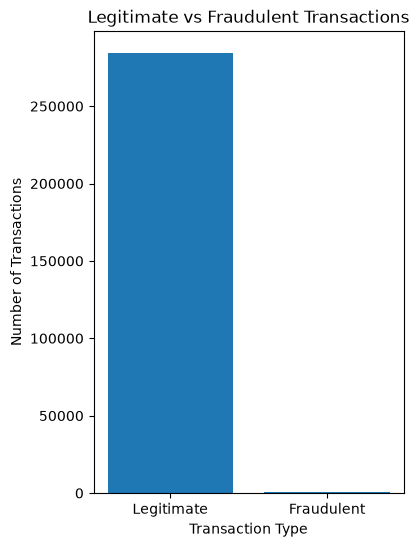

In [8]:
import matplotlib.pyplot as plt

class_counts = df["Class"].value_counts()

plt.figure(figsize=(4, 6))
plt.bar(["Legitimate", "Fraudulent"], class_counts.values)
plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.show()

In [9]:
fraud_percentage = df["Class"].mean() * 100

print(f"Fraud transactions: {fraud_percentage:.4f}%")
print(f"Legitimate transactions: {100 - fraud_percentage:.4f}%")

Fraud transactions: 0.1727%
Legitimate transactions: 99.8273%


In [10]:
df.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "min", "max"]
    )

,count,mean,median,min,max
Class,,,,,
0,284315,88.291022,22.00,0.0,25691.16
1,492,122.211321,9.25,0.0,2125.87


In [11]:
df.groupby("Class")["Time"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Class,,,,,
0,284315,94838.202258,84711.0,0.0,172792.0
1,492,80746.806911,75568.5,406.0,170348.0


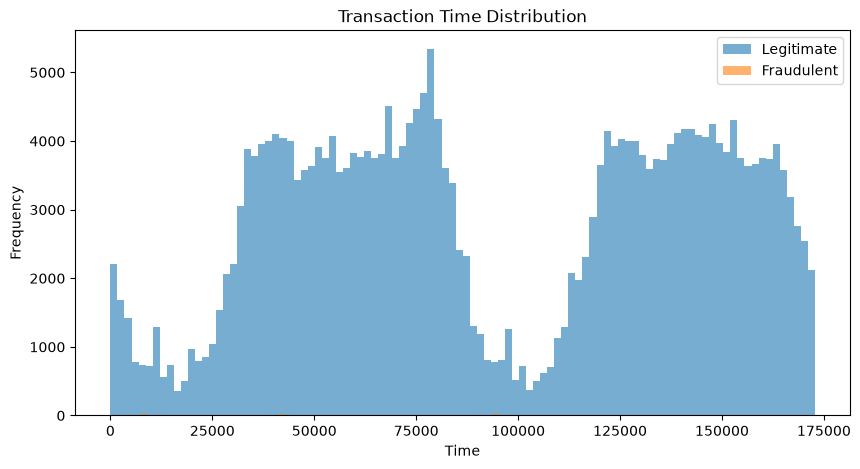

In [12]:
plt.figure(figsize=(10, 5))

plt.hist(
    df[df["Class"] == 0]["Time"],
    bins=100,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    df[df["Class"] == 1]["Time"],
    bins=100,
    alpha=0.6,
    label="Fraudulent"
)

plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [13]:
correlations = df.corr(numeric_only=True)["Class"].sort_values()

correlations

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Class     1.000000
Name: Class, dtype: float64

In [14]:
print("Most negative correlations:")
print(correlations.head(10))

print("\nMost positive correlations:")
print(correlations.tail(10))

Most negative correlations:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V18   -0.111485
V1    -0.101347
V9    -0.097733
Name: Class, dtype: float64

Most positive correlations:
V28      0.009536
V27      0.017580
V8       0.019875
V20      0.020090
V19      0.034783
V21      0.040413
V2       0.091289
V4       0.133447
V11      0.154876
Class    1.000000
Name: Class, dtype: float64


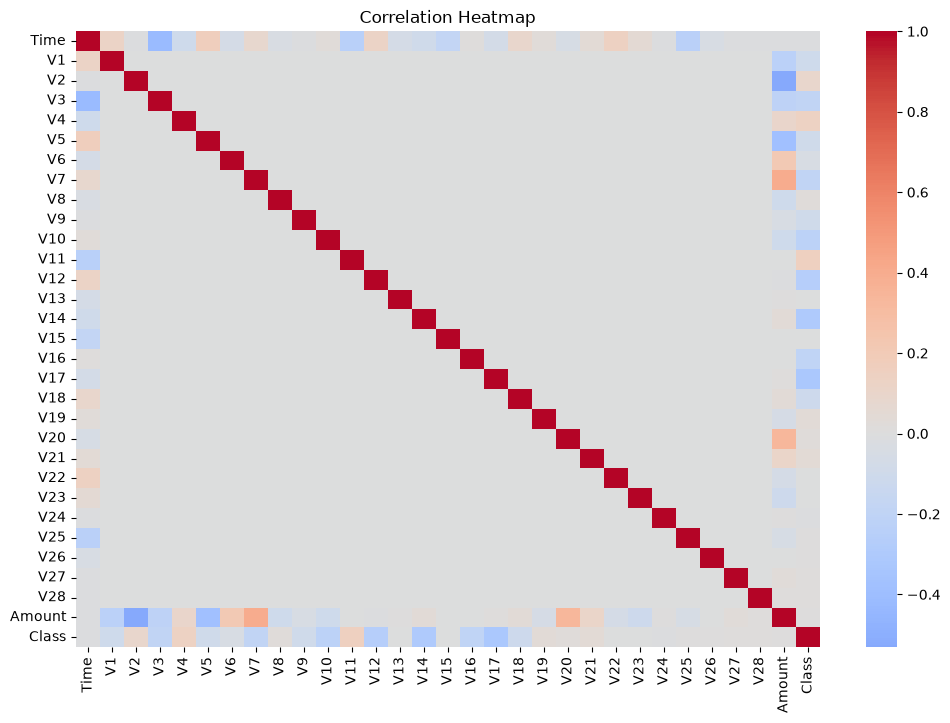

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [17]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())
print("\nColumns with missing values:")
print(missing_values[missing_values > 0])

Total missing values: 0

Columns with missing values:
Series([], dtype: int64)


In [18]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 1081


In [19]:
print("Target column:", "Class")
print("\nTarget distribution:")
print(df["Class"].value_counts())

Target column: Class

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [20]:
X = df.drop("Class", axis = 1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("Training set class distribution:")
print(y_train.value_counts())

print("\nTest set class distribution:")
print(y_test.value_counts())

Training set: (227845, 30)
Test set: (56962, 30)
Training set class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Test set class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [22]:
from imblearn.over_sampling import SMOTE

In [23]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64


In [24]:
X = df.drop("Class", axis=1)
y = df["Class"]

print(X.shape)
print(y.shape)

(284807, 30)
(284807,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(227845, 30)
(56962, 30)


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

columns_to_scale = ["Time", "Amount"]

X_train_scaled[columns_to_scale] = scaler.fit_transform(
    X_train[columns_to_scale]
)

X_test_scaled[columns_to_scale] = scaler.transform(
    X_test[columns_to_scale]
)

print("Scaling completed successfully!")

Scaling completed successfully!


In [27]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=1,
    class_weight="balanced"
)

In [30]:
print("Training Random Forest...")

rf_model.fit(X_train_smote, y_train_smote)

print("Random Forest training completed successfully!") 

Training Random Forest...
Random Forest training completed successfully!


In [31]:
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [32]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Legitimate", "Fraudulent"]
))

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
  Fraudulent       0.84      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [33]:
from sklearn.metrics import roc_auc_score

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Random Forest ROC-AUC: {roc_auc_rf:.4f}")

Random Forest ROC-AUC: 0.9636


In [34]:
from sklearn.metrics import average_precision_score

pr_auc_rf = average_precision_score(y_test, y_prob_rf)

print(f"Random Forest PR-AUC: {pr_auc_rf:.4f}")

Random Forest PR-AUC: 0.8734


[[56848    16]
 [   17    81]]


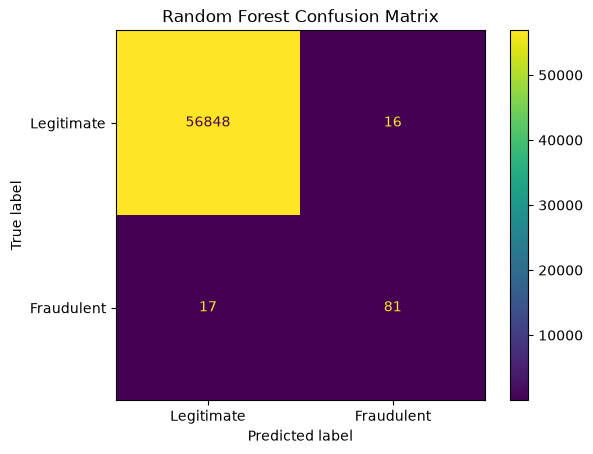

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraudulent"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [36]:
import xgboost as xgb
print(xgb.__version__)

3.4.1


In [37]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

In [38]:
print("Training XGBoost...")

xgb_model.fit(X_train_smote, y_train_smote)

print("XGBoost training completed!")

Training XGBoost...
XGBoost training completed!


In [39]:
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("XGBoost predictions generated successfully!")

XGBoost predictions generated successfully!


In [40]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=["Legitimate", "Fraudulent"]
))

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
  Fraudulent       0.74      0.89      0.81        98

    accuracy                           1.00     56962
   macro avg       0.87      0.94      0.90     56962
weighted avg       1.00      1.00      1.00     56962



In [41]:
from sklearn.metrics import roc_auc_score

roc_auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

print(f"XGBoost ROC-AUC: {roc_auc_xgb:.4f}")

XGBoost ROC-AUC: 0.9806


In [42]:
from sklearn.metrics import average_precision_score

pr_auc_xgb = average_precision_score(
    y_test,
    y_prob_xgb
)

print(f"XGBoost PR-AUC: {pr_auc_xgb:.4f}")

XGBoost PR-AUC: 0.8802


In [43]:
rf_weight = 0.40
xgb_weight = 0.60

y_prob_ensemble = (
    rf_weight * y_prob_rf
    + xgb_weight * y_prob_xgb
)

print("Ensemble probabilities generated!")

Ensemble probabilities generated!


In [44]:
y_pred_ensemble = (y_prob_ensemble >= 0.50).astype(int)

print("Ensemble predictions generated!")

Ensemble predictions generated!


In [45]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_ensemble,
    target_names=["Legitimate", "Fraudulent"]
))

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
  Fraudulent       0.80      0.88      0.84        98

    accuracy                           1.00     56962
   macro avg       0.90      0.94      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [46]:
from sklearn.metrics import roc_auc_score

roc_auc_ensemble = roc_auc_score(
    y_test,
    y_prob_ensemble
)

print(f"Ensemble ROC-AUC: {roc_auc_ensemble:.4f}")

Ensemble ROC-AUC: 0.9765


In [47]:
from sklearn.metrics import average_precision_score

pr_auc_ensemble = average_precision_score(
    y_test,
    y_prob_ensemble
)

print(f"Ensemble PR-AUC: {pr_auc_ensemble:.4f}")

Ensemble PR-AUC: 0.8813


In [50]:
import joblib
from pathlib import Path

model_dir = Path("../models")
model_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(xgb_model, model_dir / "xgboost_fraud_model.joblib")

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [51]:
model_path = model_dir / "xgboost_fraud_model.joblib"

print("Model exists:", model_path.exists())
print("Model path:", model_path)


Model exists: True
Model path: ..\models\xgboost_fraud_model.joblib


In [52]:
print(type(scaler))

<class 'sklearn.preprocessing._data.StandardScaler'>


In [53]:
[name for name in globals() if "scal" in name.lower()]

['StandardScaler',
 'scaler',
 'X_train_scaled',
 'X_test_scaled',
 'columns_to_scale']

In [54]:
import joblib

joblib.dump(
    scaler,
    model_dir / "fraud_scaler.joblib"
)

print("Scaler saved successfully!")

Scaler saved successfully!


In [55]:
scaler_path = model_dir / "fraud_scaler.joblib"

print("Scaler exists:", scaler_path.exists())
print("Scaler path:", scaler_path)

Scaler exists: True
Scaler path: ..\models\fraud_scaler.joblib


In [56]:
print("Number of scaled columns:", len(columns_to_scale))
print("Columns:")
print(columns_to_scale)

Number of scaled columns: 2
Columns:
['Time', 'Amount']


In [57]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("XGBoost expected features:", xgb_model.n_features_in_)

X_train_scaled shape: (227845, 30)
XGBoost expected features: 30
